# Equipment Failure Early Warning: Predictive Maintenance

**Author:** Brandon Kazangarare · Mining Engineering, Central South University

## Executive summary (for the maintenance manager)

| Question | Answer |
|---|---|
| **What does it do?** | Every hour, it gives each machine a risk score for *"will this machine fail in the next 24 hours?"* and raises an alarm when the risk is high. |
| **How well does it work?** | On four months it had never seen (Sep–Dec 2015), it warned of **all 220 failures**, each **24 hours** ahead. |
| **What does it cost?** | About **5 false-alarm hours per week** across the whole 100-machine fleet, coming from roughly **one false call-out every two weeks**. |
| **Is it better than simple rules?** | Yes. Ranking score (PR-AUC) **0.998**, against 0.459 for the best one-line rule (counting recent errors). |
| **What drives an alarm?** | Bursts of error messages plus a jump in one sensor: voltage, rotation, pressure or vibration, depending on which part is failing. |
| **Main caveat** | The data is **synthetic** (a Microsoft sample). Real equipment wears more gradually and real records are messier, so the approach should be re-validated on site data. |

## Contents
1. Load and check the data
2. Explore: failure rates, maintenance cycle, warning signs
3. Define the question (the label)
4. Build features from the past only
5. Split by time
6. Baselines
7. Train the model
8. Test for leaks
9. Choose the alarm threshold and test once
10. Explain the model
11. Save results for the app


## 1. Load and check the data

**What:** load the five tables. `parse_dates=["datetime"]` turns the date text into real timestamps, so we can subtract times, add hours and sort correctly.

| Table | What one row means | Type |
|---|---|---|
| `tele` | one machine, one hour: volt, rotate, pressure, vibration | **grid** (a row every hour) |
| `erro` | one error message | **event log** (only when it happens) |
| `maint` | one part replaced | event log |
| `fail` | one part failed | event log |
| `mach` | one machine: model and age | lookup (no dates) |

Most of the project is about moving information from the event logs onto the hourly grid, because the model needs one row per machine-hour.

In [ ]:
import pandas as pd

tele = pd.read_csv("/content/PdM_telemetry.csv",parse_dates=["datetime"])
erro = pd.read_csv("/content/PdM_errors.csv",parse_dates=["datetime"])
maint = pd.read_csv("/content/PdM_maint.csv",parse_dates=["datetime"])
fail = pd.read_csv("/content/PdM_failures.csv",parse_dates=["datetime"])
mach = pd.read_csv("/content/PdM_machines.csv")

### 1.1 First look at each table
**What:** print the first rows of every table to see the columns and formats.

In [ ]:
from IPython.display import display

dfs = [tele,erro,maint, fail, mach]
df_names = ["tele", "erro", "maint", "fail", "mach"]

for name, df in zip(df_names, dfs):
    print(f"--- Head of {name} dataframe ---")
    display(df.head())
    print("\n")

--- Head of tele dataframe ---


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511




--- Head of erro dataframe ---


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4




--- Head of maint dataframe ---


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4




--- Head of fail dataframe ---


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4




--- Head of mach dataframe ---


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


### 1.2 Data types and missing values
**What:** `.info()` shows each column's type and how many values are filled in. We check that `datetime` really became `datetime64` and that nothing is missing.

In [ ]:
for name, df in zip(df_names, dfs):
  print(f"--- Info of {name} dataframe ---")
  df.info()
  print("\n")

--- Info of tele dataframe ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB


--- Info of erro dataframe ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   datetime   3919 non-null   datetime64[ns]
 1   machineID  3919 non-null   int64         
 2   errorID    3919 non-null   object        
dtypes: datetime64[ns](1), int6

### 1.3 Make column names consistent
**What:** rename `failure` to `comp` in the failures table.

**Why:** merges match columns **by name**. The maintenance table calls the part `comp`, so both tables need the same name before we can join them on `["datetime", "machineID", "comp"]`.

In [ ]:
fail = fail.rename(columns={"failure": "comp"}) # Renames the 'failure' column in the 'fail' DataFrame to 'comp' for consistency with the maintenance table.

fail.info()
display(fail.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   datetime   761 non-null    datetime64[ns]
 1   machineID  761 non-null    int64         
 2   comp       761 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 18.0+ KB


,datetime,machineID,comp
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


### 1.4 Duplicate rows
**What:** count fully repeated rows in each table. Duplicates would double-count readings or failures.

In [ ]:
for name, df in zip(df_names, dfs):
  print(f"---Dupes in {name} dataframe---")
  print(df.duplicated().sum())
  print("\n")

---Dupes in tele dataframe---
0


---Dupes in erro dataframe---
0


---Dupes in maint dataframe---
0


---Dupes in fail dataframe---
0


---Dupes in mach dataframe---
0




### 1.5 Time coverage and completeness
**What:** check the date ranges and count the rows per machine.

**Why this matters for time data:** later, `rolling(24)` means "the last 24 **rows**". That only equals "the last 24 **hours**" if every machine has exactly one row per hour, with no gaps.

In [ ]:
# This code snippet helps in understanding the temporal and machine-specific distribution of data.

# 1. Prints the earliest and latest datetime in the 'tele' dataframe.
#    This shows the overall time span of the telemetry data.
print(tele.datetime.min(), "to", tele.datetime.max())

# 2. Prints the earliest and latest datetime in the 'maint' dataframe.
#    This shows the overall time span of the maintenance data.
print(maint.datetime.min(), "to", maint.datetime.max())

# 3. Groups the 'tele' dataframe by 'machineID', counts the number of records for each machine,
#    and then provides descriptive statistics for these counts. This reveals how many telemetry
#    records exist for each machine, giving insights into data volume per machine.
print(tele.groupby("machineID").size().describe())

2015-01-01 06:00:00 to 2016-01-01 06:00:00
2014-06-01 06:00:00 to 2016-01-01 06:00:00
count     100.0
mean     8761.0
std         0.0
min      8761.0
25%      8761.0
50%      8761.0
75%      8761.0
max      8761.0
dtype: float64


> **Findings: data quality**
> - **No missing values** and **no duplicate rows** in any table.
> - Telemetry runs from **1 Jan 2015 06:00 to 1 Jan 2016 06:00**. Maintenance records start earlier, in **June 2014**, which gives service history from day one.
> - **Every machine has exactly 8,761 hourly rows** (365 days × 24 h + 1). The time grid is complete, so rolling windows of *n* rows really cover *n* hours.
>
> **Why it matters:** real mine data almost always has gaps (sensor dropouts, radio dead zones underground). Here the grid is clean, so no resampling or gap-filling is needed. On real data, this check would come first.

## 2. Explore the data

### 2.1 How common are errors, failures and services?
**What:** count each error type, failed part, replaced part and machine model. Then count failures per machine, including machines that never failed.

In [ ]:
print(erro.errorID.value_counts())
print(fail.comp.value_counts())
print(maint.comp.value_counts())
print(mach.model.value_counts())
print(mach.age.describe())

per_machine = fail.groupby("machineID").size().reindex(mach.machineID, fill_value=0)
print(per_machine.describe())
print((per_machine == 0).sum(), "machine never failed")
print(fail.duplicated(["machineID", "datetime"]).sum(), "failures share an hour with another")

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64
comp
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64
count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64
count    100.000000
mean       7.610000
std        3.598246
min        0.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       19.000000
dtype: float64
2 machine never failed
42 failures share an hour with another


> **Findings**
> - **Errors:** error1 is the most common (1,010) and error5 the rarest (356).
> - **Failures by part:** comp2 fails most (259), then comp1 (192), comp4 (179) and comp3 (131).
> - **Replacements** are spread evenly across the four parts (804–863 each), which fits a regular service schedule.
> - **Fleet:** 100 machines across 4 models (35, 32, 17 and 16 machines), aged 0–20 years (average 11.3).
> - **Failures per machine:** 7.6 on average, ranging from 0 to 19. **2 machines never failed.**
> - **42 failures share the same hour** with another part failing on the same machine.
>
> **Why it matters:** 761 failures in 876,100 machine-hours is **under 0.1% of hours**. Failures are rare, so accuracy will be a misleading score. We'll need metrics that focus on the rare failure cases.

### 2.2 Do some models or ages fail more?
**What:** build one row per machine with its model, age and failure count, then compare groups.

**Important:** compare the **mean** (failures per machine), not the **sum**, because the groups have different numbers of machines.

        count  sum   mean
model                    
model1     16  189  11.81
model2     17  168   9.88
model3     35  221   6.31
model4     32  183   5.72
           count  sum  mean
age_group                  
0-5           21  124  5.90
6-10          26  140  5.38
11-15         24  221  9.21
16-20         29  276  9.52
           age  failures
age       1.00      0.47
failures  0.47      1.00


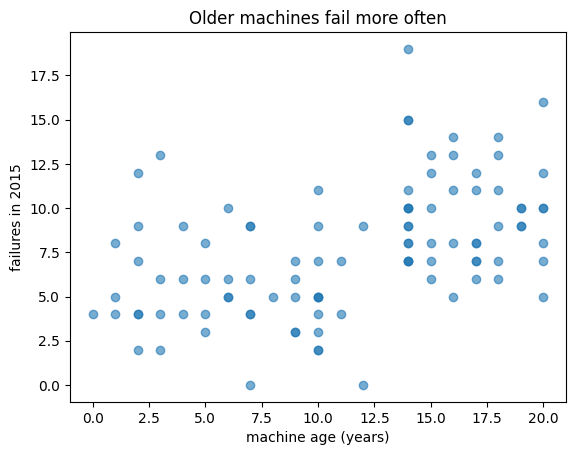

In [ ]:
import matplotlib.pyplot as plt

# one row per machine: model, age, and how many times it failed
m = mach.set_index("machineID").assign(failures=per_machine)

# failures by model
print(m.groupby("model").failures.agg(["count", "sum", "mean"]).round(2))

# failures by age group
m["age_group"] = pd.cut(m.age, bins=[-1, 5, 10, 15, 20],
                        labels=["0-5", "6-10", "11-15", "16-20"])
print(m.groupby("age_group", observed=True).failures.agg(["count", "sum", "mean"]).round(2))

# age vs failures, one dot per machine
print(m[["age", "failures"]].corr().round(2))
plt.scatter(m.age, m.failures, alpha=0.6)
plt.xlabel("machine age (years)")
plt.ylabel("failures in 2015")
plt.title("Older machines fail more often")
plt.show()

> **Findings**
>
> | Model | Machines | Total failures | **Failures per machine** |
> |---|---|---|---|
> | model1 | 16 | 189 | **11.8** |
> | model2 | 17 | 168 | **9.9** |
> | model3 | 35 | 221 | **6.3** |
> | model4 | 32 | 183 | **5.7** |
>
> - Model3 has the **most failures in total** only because it has the most machines. **Per machine, model1 is the least reliable**, failing about twice as often as model3 or model4.
> - **Older machines fail more:** ages 11–20 average 9.2–9.5 failures a year, against 5.4–5.9 for ages 0–10. The correlation between age and failures is **0.47** (moderate).
>
> **For the maintenance team:** model1 machines and machines over 10 years old deserve closer attention. Age and model become model inputs in Section 4.

### 2.3 How do failures relate to maintenance?
**What:**
1. Merge each failure with the maintenance log using `indicator=True`. This adds a `_merge` column saying whether each failure found a matching maintenance record (`both`) or not (`left_only`).
2. Measure the days between replacements of the same part on the same machine.

_merge
both          743
left_only      18
right_only      0
Name: count, dtype: int64
count    2886.000000
mean       60.440055
std        59.823661
min         5.000000
25%        15.000000
50%        45.000000
75%        75.000000
max       492.000000
Name: datetime, dtype: float64
<DatetimeArray>
['2015-01-02 03:00:00']
Length: 1, dtype: datetime64[ns]


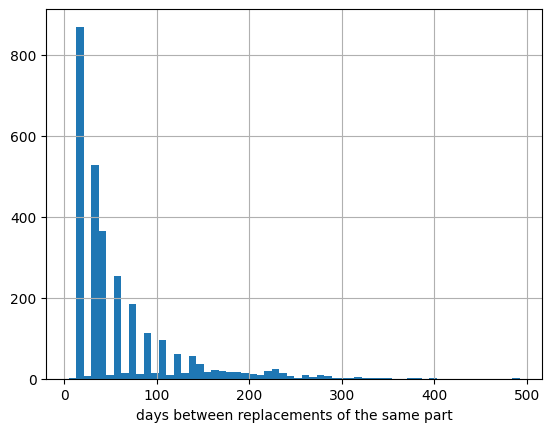

In [ ]:
chk = fail.merge(maint, on=["datetime", "machineID", "comp"], how="left", indicator=True)
print(chk["_merge"].value_counts())

gaps = (maint.sort_values("datetime").groupby(["machineID", "comp"]).datetime.diff().dt.days)
print(gaps.describe())
print(chk[chk["_merge"] == "left_only"].datetime.unique())
gaps.hist(bins=60)
plt.xlabel("days between replacements of the same part")
plt.show()

> **Findings**
> - **743 of 761 failures** have a matching replacement record logged at the failure hour. The **18 that don't** all fall at one timestamp, 2 Jan 2015 03:00, within the first day of data. That's a start-of-data artifact, not a coding error, and those hours are dropped later anyway.
> - The gaps between replacements are **multiples of 15 days**: 15 days is the most common gap (870 times), then 30, 45, 60 and so on. This is the **scheduled maintenance cycle**.
>
> **Why it matters:**
> - Failures happen **between** scheduled visits. Catching them is the business value of this project.
> - Every failure also creates a replacement record **at the failure hour**. Any "time since last replacement" feature must only count replacements **strictly before** the current hour, or it leaks the failure (handled in Section 4).

### 2.4 Is there a warning sign before failures?
**What:** for every failure, cut out the 7 days of sensor readings before it, re-clock them as **"hours before failure"** (0 = failure hour), then average across all failures of the same part.

**Why:** failures happen on different dates, so their warning signs are scattered across the calendar. Lining them all up on the failure hour makes the shared pattern visible while random noise cancels out.

**Key code ideas:**
- `by_m` is a dictionary of 100 small tables, one per machine, so each loop searches 8,761 rows instead of 876,100.
- `fail.itertuples()` loops through failures one at a time (`f.machineID`, `f.datetime`, `f.comp`).
- `pd.Timedelta(days=7)` is a length of time, used to find the start of each window.
- The grey dashed line in each panel is that sensor's normal yearly average.

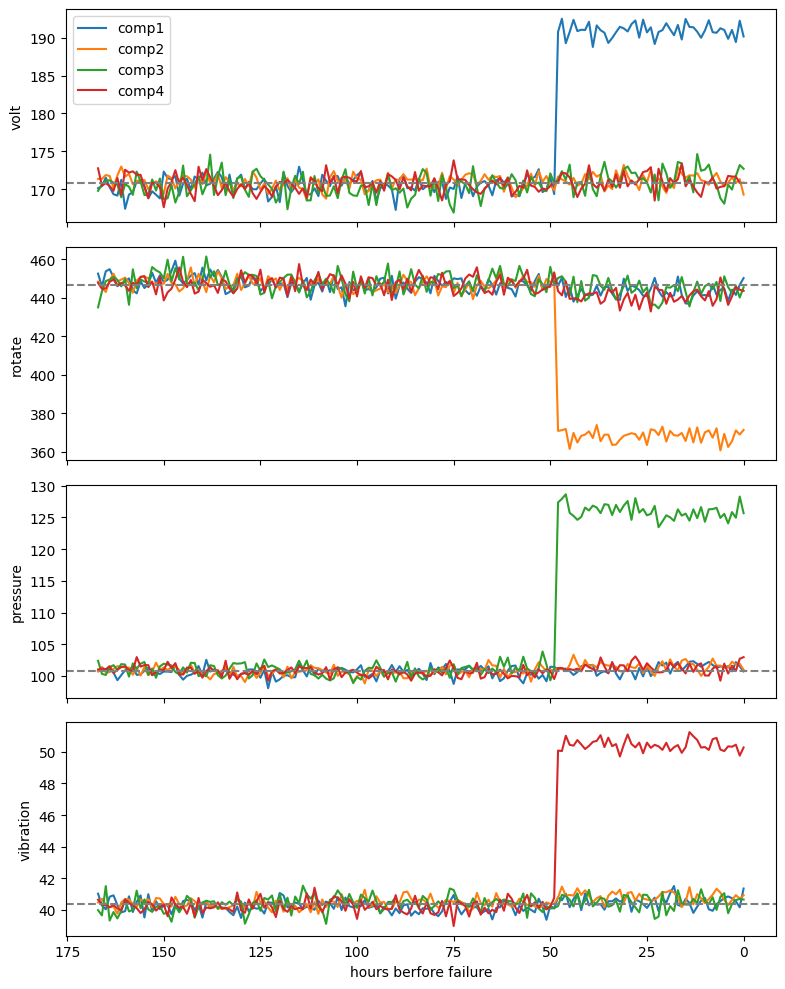

In [ ]:
sensors = ["volt","rotate","pressure","vibration"]
comps = ["comp1","comp2","comp3","comp4"]
tele = tele.sort_values(["machineID","datetime"])
by_m = dict(tuple(tele.groupby("machineID")))

rows = []
for f in fail.itertuples():
  m = by_m[f.machineID]
  w = m[(m.datetime > f.datetime - pd.Timedelta(days=7)) & (m.datetime <= f.datetime)].copy()
  w["hours_before"] = (f.datetime - w.datetime).dt.total_seconds() / 3600
  w["comp"] = f.comp
  rows.append(w)
ev = pd.concat(rows)
prof = ev.groupby(["comp", "hours_before"])[sensors].mean()

fig, axes = plt.subplots(4, 1, figsize=(8, 10 ), sharex=True)
for ax, s in zip(axes, sensors):
  for c in comps:
    prof.loc[c, s].plot(ax=ax, label=c)

  ax.axhline(tele[s].mean(), ls="--", color="grey")
  ax.set_ylabel(s)
axes[0].legend()
axes[-1].invert_xaxis()
axes[-1].set_xlabel("hours berfore failure")
plt.tight_layout()
plt.show()

> **Key finding: each part has its own warning sensor**
>
> | Part | Warning sensor | Normal → before failure |
> |---|---|---|
> | comp1 | volt | ~171 → ~191 |
> | comp2 | rotate | ~447 → ~370 |
> | comp3 | pressure | ~101 → ~126 |
> | comp4 | vibration | ~40 → ~50 |
>
> - The change starts **about 48 hours before failure** and stays until the part breaks.
> - The changes are **sudden steps**, not gradual drifts. This is a sign of synthetic data: real parts usually wear gradually.
>
> **Why it matters:** a **24-hour warning is realistic**, because the signal already exists a full day earlier. It also tells us which sensors the model should rely on.
>
> **For the maintenance team:** a sustained jump in one sensor points to **which part** is about to fail, so the right spare can be prepared.

## 3. Define the question (the label)

**Question:** *at this hour, will this machine have a failure within the next **H = 24** hours?* (yes = 1, no = 0)

**Why 24 hours:** long enough for a crew and spare parts to get to the machine, and fully inside the ~48-hour window where warning signs exist (Section 2.4). A 72-hour horizon would label normal-looking hours as "failing" and teach the model noise.

**How `merge_asof` builds the label:**
- An *as-of* merge matches each hour to the **nearest** failure in time, rather than requiring an exact match.
- `by="machineID"`: only match failures on the **same machine**.
- `direction="forward"`: look **ahead** to the next failure. This is the only place we look into the future, because we're writing the answer key, not a feature.
- `allow_exact_matches=False`: "next" means **strictly after** this hour.
- `drop_duplicates()`: the 42 same-hour failures count as one event (719 events in total).

> ⚠️ `next_fail` and `hrs_to_fail` contain the answer. They must **never** be used as model inputs.

In [ ]:
H = 24 # warning horizon in hours

f_times = (fail[["machineID", "datetime"]].drop_duplicates()
              .rename(columns={"datetime": "next_fail"}).sort_values("next_fail"))

df = pd.merge_asof(tele.sort_values("datetime"), f_times,
                   left_on="datetime", right_on="next_fail", by="machineID",
                   direction="forward", allow_exact_matches=False)

df["hrs_to_fail"] = (df.next_fail - df.datetime).dt.total_seconds() / 3600
df["y"] = (df.hrs_to_fail <= H).astype(int)
print(df.y.mean())

0.019614199292318227


### 3.1 Spot-check the label by hand
**What:** print the hours around machine 1's first failure (5 Jan 2015, 06:00). A plausible summary number can hide a logic error; looking at one real case can't.

In [ ]:
ft = f_times[f_times.machineID == 1].next_fail.iloc[0]  # machine 1s first failure
one = df[df.machineID ==1].sort_values("datetime")
print(ft)
print(one[(one.datetime >= ft - pd.Timedelta(hours=27)) &
          (one.datetime <= ft + pd.Timedelta(hours=2))]
      [["datetime", "next_fail", "hrs_to_fail", "y"]])

2015-01-05 06:00:00
                datetime           next_fail  hrs_to_fail  y
6922 2015-01-04 03:00:00 2015-01-05 06:00:00         27.0  0
7053 2015-01-04 04:00:00 2015-01-05 06:00:00         26.0  0
7111 2015-01-04 05:00:00 2015-01-05 06:00:00         25.0  0
7233 2015-01-04 06:00:00 2015-01-05 06:00:00         24.0  1
7370 2015-01-04 07:00:00 2015-01-05 06:00:00         23.0  1
7492 2015-01-04 08:00:00 2015-01-05 06:00:00         22.0  1
7534 2015-01-04 09:00:00 2015-01-05 06:00:00         21.0  1
7629 2015-01-04 10:00:00 2015-01-05 06:00:00         20.0  1
7761 2015-01-04 11:00:00 2015-01-05 06:00:00         19.0  1
7821 2015-01-04 12:00:00 2015-01-05 06:00:00         18.0  1
7978 2015-01-04 13:00:00 2015-01-05 06:00:00         17.0  1
8014 2015-01-04 14:00:00 2015-01-05 06:00:00         16.0  1
8190 2015-01-04 15:00:00 2015-01-05 06:00:00         15.0  1
8225 2015-01-04 16:00:00 2015-01-05 06:00:00         14.0  1
8309 2015-01-04 17:00:00 2015-01-05 06:00:00         13.0  1
8467

> **Findings**
> - 27–25 hours before the failure: `y = 0`.
> - **24 hours to 1 hour before: `y = 1`** (exactly 24 rows).
> - **At the failure hour: `y = 0`**, and `next_fail` moves on to the next failure (6 Mar). That's correct, because at that hour this failure is no longer in the future.
> - Overall, **1.96%** of hours are labelled 1, which matches the arithmetic: 719 events × 24 h ÷ 876,100 rows ≈ 1.97%.
>
> **Why it matters:** two independent checks agree, so the label is right. The model can only be as good as its answer key.

## 4. Build features from the past only

**The rule for every feature:** at hour *t*, use only information a technician standing next to the machine at hour *t* could know: **the past, from the same machine**.

| Feature family | How | Count |
|---|---|---|
| Rolling sensor stats | mean and standard deviation of each sensor over the last **3 h** (reacts fast) and **24 h** (smoother) | 16 |
| Recent errors | count of each error type in the last 24 h (event log → pivot → rolling sum) | 5 |
| Service history | hours since each part was last replaced (`merge_asof`, `direction="backward"`, strictly before) | 4 |
| Machine | age, plus model as 4 yes/no columns (one-hot encoding, so models get no fake order) | 5 |

**Details that prevent mistakes:**
- `groupby("machineID")` before every rolling window. Without it, one machine's window would spill into the previous machine's data.
- `min_periods=w`: no value until a full window exists, rather than a misleading average of 2–3 points.
- Never use `rolling(..., center=True)`, because a centred window includes future hours.
- `fillna(9999)` for "no replacement on record yet" means "a very long time ago".

> ⚠️ **Rerun trap:** this cell builds on `df`. Running it twice merges `mach` twice and creates duplicate columns. If you change it, rerun from Section 3. Expected shape: **(876,100, 39)**.

In [ ]:
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
g = df.groupby("machineID")
for s in sensors:
    for w in [3, 24]:
        df[f"{s}_mean_{w}h"] = g[s].transform(lambda x: x.rolling(w, min_periods=w).mean())
        df[f"{s}_std_{w}h"]  = g[s].transform(lambda x: x.rolling(w, min_periods=w).std())

erro["n"] = 1
e = erro.pivot_table(index=["machineID", "datetime"], columns="errorID",
                     values="n", aggfunc="sum", fill_value=0).reset_index()
ecols = [c for c in e.columns if str(c).startswith("error")]
df = df.merge(e, on=["machineID", "datetime"], how="left")
df[ecols] = df[ecols].fillna(0)
for c in ecols:
    df[f"{c}_24h"] = df.groupby("machineID")[c].transform(lambda x: x.rolling(24, min_periods=1).sum())
df = df.drop(columns=ecols)

df = df.sort_values("datetime")
for c in comps:
    m = (maint[maint.comp == c][["machineID", "datetime"]]
           .rename(columns={"datetime": f"last_{c}"}).sort_values(f"last_{c}"))
    df = pd.merge_asof(df, m, left_on="datetime", right_on=f"last_{c}", by="machineID",
                       direction="backward", allow_exact_matches=False)
    df[f"hrs_since_{c}"] = (df.datetime - df[f"last_{c}"]).dt.total_seconds() / 3600
    df = df.drop(columns=f"last_{c}")
df[[f"hrs_since_{c}" for c in comps]] = df[[f"hrs_since_{c}" for c in comps]].fillna(9999)

df = df.merge(mach, on="machineID", how="left")
df = pd.get_dummies(df, columns=["model"])
print(df.shape)

(876100, 39)


### 4.1 Which features differ before failures?
**What:** compare each feature's average for `y = 0` (normal hours) and `y = 1` (24 h before a failure).

In [ ]:
print(df.groupby("y")[[c for c in df.columns if c.endswith("_24h")]].mean().T)

y                            0           1
volt_mean_24h       170.672536  175.859853
volt_std_24h         14.918810   14.925200
rotate_mean_24h     447.170863  418.159367
rotate_std_24h       49.956124   49.571851
pressure_mean_24h   100.767609  105.290930
pressure_std_24h     10.047377   10.022347
vibration_mean_24h   40.337529   42.783488
vibration_std_24h     5.002064    5.000880
error1_24h            0.022693    0.276362
error2_24h            0.020090    0.374418
error3_24h            0.015693    0.382565
error4_24h            0.016326    0.198673
error5_24h            0.004928    0.250873


> **Findings**
> - **Error counts are 10–50× higher** in the 24 hours before a failure (for example, error5 rises from about 0.005 to 0.25). They're likely to be the strongest features.
> - **Sensor means shift only a little** on average (volt ~171 → ~176, rotate ~447 → ~418). Each sensor only reacts to **one** of the four parts, so averaging over all failures dilutes the jump. The model has to combine sensors to separate failure types.
> - **Standard deviations barely change** (volt std 14.92 vs. 14.93), so they're likely to be weak features.

### 4.2 Leak check: does the replacement counter reset too early?
**What:** look at `hrs_since_comp4` around machine 1's comp4 failure (5 Jan, 06:00). It must keep growing up to the failure hour and reset only afterwards.

In [ ]:
cols = ["datetime", "y", "hrs_since_comp4"]
print(df[(df.machineID == 1) &
         (df.datetime.between("2015-01-05 03:00", "2015-01-05 09:00"))][cols])

                datetime  y  hrs_since_comp4
9372 2015-01-05 03:00:00  1           4149.0
9489 2015-01-05 04:00:00  1           4150.0
9511 2015-01-05 05:00:00  1           4151.0
9655 2015-01-05 06:00:00  0           4152.0
9773 2015-01-05 07:00:00  0              1.0
9872 2015-01-05 08:00:00  0              2.0
9970 2015-01-05 09:00:00  0              3.0


> **Findings:** the counter reaches **4,152 hours at the failure hour** and resets to **1 at 07:00**, one hour later. The model never sees the replacement before the failure happens. ✅

## 5. Split by time

| Period | Use | Rows |
|---|---|---|
| Jan – Aug 2015 | training | 580,300 |
| **1 Sep** | **gap (24 h)** | dropped |
| Sep – Dec 2015 | test, used once at the end | 291,100 |

**Why not a random split?** Neighbouring hours are nearly identical. If 10:00 and 12:00 are in training, the model has practically seen 11:00, so the score measures memory, not prediction.

**Why the gap?** A training row on 31 Aug 23:00 gets its label from failures up to 1 Sep 23:00. Without a gap, test-period failures would leak into training labels. The gap must be at least as long as the horizon H.

**Also:** `dropna` removes the first 23 hours of each machine (no full 24 h window yet), and the `drop` list removes ID, time and answer columns from the model inputs. The `assert` stops the notebook if an answer column slips through.

In [ ]:
df = df.dropna(subset=[f"{s}_std_24h" for s in sensors])

train =  df[df.datetime < "2015-09-01"]
test = df[df.datetime >= "2015-09-02"] # 24 hour gap = label horizon

drop = ["datetime", "machineID", "y", "next_fail", "hrs_to_fail"]
X_tr, y_tr = train.drop(columns=drop), train.y
X_te, y_te = test.drop(columns=drop), test.y

print(len(train), len(test), y_tr.mean(), y_te.mean())
assert not{"next_fail", "hrs_to_fail", "y"} & set(X_tr.columns)

580300 291100 0.019598483542995003 0.01824115424252834


> **Findings**
> - Training: **580,300 rows**, 1.96% positive. Test: **291,100 rows**, 1.82% positive. The rates are similar, so the periods are comparable.
> - The row counts add up: 876,100 − 2,300 (first 23 h × 100 machines) − 2,400 (gap day) = 871,400 = 580,300 + 291,100.
> - The `assert` passed, so no answer columns are in the inputs. The model uses **34 input features**.

## 6. Baselines: what do simple rules score?

**Metric: PR-AUC** (precision–recall area under the curve), from 0 to 1.
- **Precision:** when the alarm rings, how often is a failure really coming?
- **Recall:** of all real failures, how many did we catch?
- PR-AUC summarises the trade-off across **every** threshold, so it measures how well risky hours are **ranked** above safe ones. Random guessing scores the share of positive hours (about 0.018).

**Why not accuracy?** Always predicting "no failure" is **98.2% accurate** and catches nothing.

**Rules tested:** risk = age of the oldest part; risk = number of errors in the last 24 h.

In [ ]:
from sklearn.metrics import average_precision_score as ap

print("random guessing PR-AUC:", y_te.mean())

age_rule = X_te[[f"hrs_since_{c}" for c in comps]].max(axis=1)
print("'oldest part' rule PR-AUC:", ap(y_te, age_rule))

err_rule = X_te[[c for c in X_te.columns if c.startswith("error") and c.endswith("_24h")]].sum(axis=1)
print("'recent errors' rule PR-AUC:", ap(y_te, err_rule))

random guessing PR-AUC: 0.01824115424252834
'oldest part' rule PR-AUC: 0.020861652717398902
'recent errors' rule PR-AUC: 0.4588886246566179


> **Findings**
>
> | Method | Test PR-AUC |
> |---|---|
> | Random guessing | 0.018 |
> | "Oldest part" rule | 0.021 |
> | "Recent errors" rule | **0.459** |
>
> - **Part age is almost useless:** the 15-day service cycle resets parts regularly, so "time since replacement" mostly tracks the schedule, not wear.
> - **Recent errors are a strong one-line rule** (about 25× random). This is the bar the model must clearly beat.

## 7. Train the model

**Model:** `HistGradientBoostingClassifier` (gradient boosting).
- **Intuition:** 300 small decision trees built one after another; each new tree corrects the mistakes of the previous ones. "Hist" means values are grouped into bins first, which makes it fast on large data.
- `learning_rate=0.05`: each tree corrects only a little, which is slower but steadier.
- `class_weight="balanced"`: failure hours (~2%) count about 50× more, so the model can't ignore them.
- `random_state=42`: the same result every run.

**Three sets, not two:** fit on **Jan–Jun**, validate on **Jul–Aug** (with its own 1-day gap), and keep the test set untouched. All decisions are made on validation.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

def make_model():
    return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                          class_weight="balanced", random_state=42)

fit = train[train.datetime <  "2015-07-01"]
val = train[train.datetime >= "2015-07-02"]          # gap again
X_fit, y_fit = fit.drop(columns=drop), fit.y
X_val, y_val = val.drop(columns=drop), val.y

clf_val = make_model().fit(X_fit, y_fit)
p_val = clf_val.predict_proba(X_val)[:, 1]
print("validation PR-AUC:", ap(y_val, p_val))

validation PR-AUC: 0.999696451265955


> **Findings:** validation PR-AUC = **0.9997**, far above the best baseline (0.459).
>
> A near-perfect score is a warning sign in itself, so the next section tries to prove it isn't a leak.

## 8. Test for leaks (ablation)

**What:** retrain using one feature group at a time. If one group alone scored near-perfectly, that group would probably contain the answer.

In [ ]:
groups = {
    "sensors only": [c for c in X_fit.columns if any(c.startswith(s) for s in sensors)],
    "errors only":  [c for c in X_fit.columns if c.startswith("error")],
    "raw hourly sensors": sensors,
}
for name, cols in groups.items():
    m = make_model().fit(X_fit[cols], y_fit)
    print(name, ap(y_val, m.predict_proba(X_val[cols])[:, 1]))

sensors only 0.2529965137912442
errors only 0.672832725443744
raw hourly sensors 0.06987525600491619


### 8.1 Harder task: warn 24–48 hours ahead
**What:** relabel so `y = 1` only between 24 and 48 hours before a failure, and retrain. A real signal should get weaker the further ahead we look.

In [ ]:
y2_fit = ((fit.hrs_to_fail > 24) & (fit.hrs_to_fail <= 48)).astype(int)
y2_val = ((val.hrs_to_fail > 24) & (val.hrs_to_fail <= 48)).astype(int)
m = make_model().fit(X_fit, y2_fit)
print("24-48 h ahead", ap(y2_val, m.predict_proba(X_val)[:, 1]))

24-48 h ahead 0.8305731100490047


> **Findings**
>
> | Features used | Validation PR-AUC |
> |---|---|
> | All features | **0.9997** |
> | Error counts only | 0.67 |
> | Sensor features only | 0.25 |
> | Raw hourly sensors only | 0.07 |
> | All features, 24–48 h ahead | 0.83 |
>
> - **No single group gives the answer away**, so there's no sign of a leak.
> - The model succeeds by **combining** error bursts with sensor shifts.
> - Raw readings alone score only 0.07, so the **rolling features did the real work**.
> - Predicting further ahead is harder (0.83), as expected from an honest signal. Sensors only jump about 48 h before failure.
>
> **Honest conclusion:** the synthetic data contains unusually clear warning signs, which is why the score is so high. The ablation shows the score is earned, not leaked.

## 9. Choose the alarm threshold

The model outputs a risk from 0 to 1 every hour. The **threshold** is where the alarm sounds: lower means earlier warnings but more false alarms.

`event_report()` turns hourly predictions into the three things a manager asks about:
1. **Caught:** did an alarm fire in the 24 h before each real failure?
2. **Warning time:** how many hours before the failure did the first alarm fire?
3. **False alarms:** alarm hours with no failure coming, per week, across the fleet.

Thresholds are compared on **validation (Jul–Aug)** only.

In [ ]:
def event_report(frame, probs, thr, H=24):
    fr = frame[["machineID", "datetime", "y"]].assign(alarm=probs >= thr)
    by_m = dict(tuple(fr.groupby("machineID")))
    start = fr.datetime.min() + pd.Timedelta(hours=H)
    evs = f_times[(f_times.next_fail >= start) & (f_times.next_fail <= fr.datetime.max())]
    caught, leads = 0, []
    for e in evs.itertuples():
        m = by_m[e.machineID]
        w = m[(m.datetime >= e.next_fail - pd.Timedelta(hours=H))
              & (m.datetime < e.next_fail) & m.alarm]
        if len(w):
            caught += 1
            leads.append((e.next_fail - w.datetime.min()).total_seconds() / 3600)
    weeks = (fr.datetime.max() - fr.datetime.min()).days / 7
    false_hrs = (fr.alarm & (fr.y == 0)).sum() / weeks
    return caught, len(evs), (sum(leads) / len(leads) if leads else 0), false_hrs

for thr in [0.3, 0.5, 0.7, 0.9]:
    c, n, lead, fa = event_report(val, p_val, thr)
    print(f"thr {thr}: caught {c}/{n}, mean warning {lead:.0f} h, {fa:.0f} false-alarm hours/week")

thr 0.3: caught 113/113, mean warning 24 h, 2 false-alarm hours/week
thr 0.5: caught 113/113, mean warning 24 h, 0 false-alarm hours/week
thr 0.7: caught 113/113, mean warning 24 h, 0 false-alarm hours/week
thr 0.9: caught 113/113, mean warning 24 h, 0 false-alarm hours/week


> **Findings (validation)**
>
> | Threshold | Caught | Warning | False-alarm hours/week |
> |---|---|---|---|
> | 0.3 | 113/113 | 24 h | 2 |
> | **0.5** | **113/113** | **24 h** | **0** |
> | 0.7 | 113/113 | 24 h | 0 |
> | 0.9 | 113/113 | 24 h | 0 |
>
> **Decision:** threshold **0.5**, the lowest setting with zero false alarms. Lower thresholds catch failures more readily, so the lowest clean one gives the most safety margin. 24 h is the maximum possible warning, because that's the label horizon.

### 9.1 Final test (run once)
**What:** retrain on all of Jan–Aug with the same settings, then score the untouched test period (Sep–Dec) **once**, using the threshold chosen on validation.

> ⚠️ Don't change the threshold after seeing these results. That would turn the test set into a second validation set and make the result optimistic.

In [ ]:
THR = 0.5   # chosen on validation: lowest threshold with zero false alarms
final = make_model().fit(X_tr, y_tr)          # retrain on all of Jan–Aug
p_te = final.predict_proba(X_te)[:, 1]
print("test PR-AUC:", ap(y_te, p_te))
c, n, lead, fa = event_report(test, p_te, THR)
print(f"TEST: caught {c}/{n}, mean warning {lead:.0f} h, {fa:.0f} false-alarm hours/week")

test PR-AUC: 0.9983022605791877
TEST: caught 220/220, mean warning 24 h, 5 false-alarm hours/week


> **Final results (test set: Sep–Dec 2015, never seen during training)**
>
> | Measure | Result |
> |---|---|
> | Failures caught | **220 / 220** |
> | Warning time | **24 h** before every failure |
> | False alarms | **~5 alarm-hours per week** across 100 machines (≈0.03% of 16,800 machine-hours) |
> | PR-AUC | **0.998** (validation: 0.9997) |
>
> - The small drop from validation to test is normal, and it shows the test data really was unseen.
> - False alarms are counted in **hours**. The 80 false-alarm hours in the test period came from just **10 separate alarm episodes** over 17 weeks: about **one false call-out every two weeks** for the whole fleet.
>
> **For the maintenance team:** on this data, the model would have given a full day's notice of every breakdown, at the cost of about one unnecessary check every two weeks.

## 10. Explain the model: permutation importance

**What:** shuffle one feature at a time so it becomes nonsense, and measure how much PR-AUC drops. A big drop means the model relies on that feature. It runs on a 20,000-row sample to save time.

error5_24h            0.130026
error4_24h            0.084137
error1_24h            0.080095
volt_mean_24h         0.062759
pressure_mean_24h     0.058129
vibration_mean_24h    0.052994
error2_24h            0.037934
error3_24h            0.034994
rotate_mean_24h       0.025033
hrs_since_comp1       0.010241
hrs_since_comp3       0.007903
hrs_since_comp4       0.006209
hrs_since_comp2       0.004036
age                   0.002538
model_model3          0.001553
dtype: float64


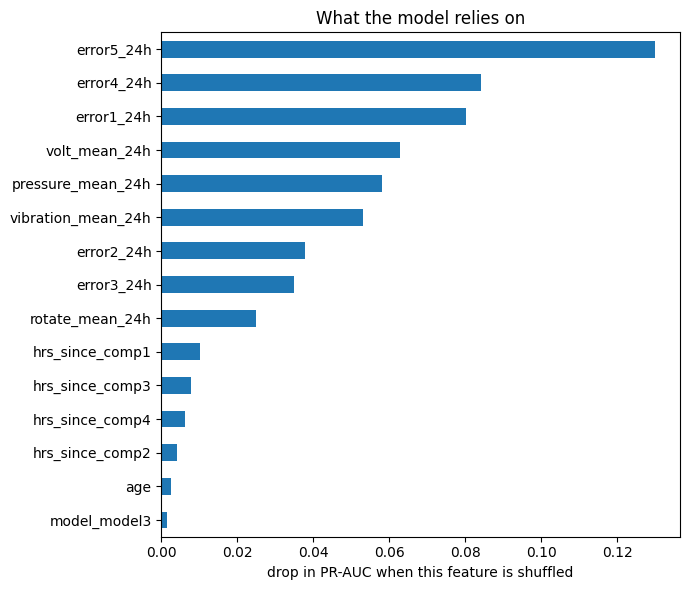

In [ ]:
from sklearn.inspection import permutation_importance

sample = X_te.sample(20000, random_state=0)
r = permutation_importance(final, sample, y_te.loc[sample.index],
                           scoring="average_precision", n_repeats=5, random_state=0)
imp = pd.Series(r.importances_mean, index=sample.columns).sort_values(ascending=False)
print(imp.head(15))

imp.head(15)[::-1].plot.barh(figsize=(7, 6))
plt.xlabel("drop in PR-AUC when this feature is shuffled")
plt.title("What the model relies on")
plt.tight_layout()
plt.show()

> **Findings**
> 1. **Error counts rank first** (error5, error4, error1), matching Section 4.1.
> 2. Next come the **24-hour means of volt, pressure, vibration and rotate**: the four warning sensors from Section 2.4.
> 3. **Replacement times, age and model matter little**, consistent with the "oldest part" baseline scoring near random.
> 4. **Standard-deviation features barely appear**, as predicted in Section 4.1.
> 5. **24 h means beat 3 h means:** averaging over a day smooths hourly noise, so the jump stands out.
>
> **Why it matters:** the model relies on the same signals the exploration found by eye. It learned the real pattern, not a shortcut.

## 11. Save results for the Streamlit app

**What:** save the trained model (`joblib`), the test-period predictions and the feature importances as small files. The dashboard reads these instead of the 79 MB telemetry file, so it loads quickly and nothing has to be retrained.

In [ ]:
import joblib
joblib.dump(final, "pdm_model.joblib")
test.assign(risk=p_te)[["machineID", "datetime", "risk", "y"]].to_csv("test_predictions.csv", index=False)
imp.to_csv("feature_importance.csv")

## Conclusions

1. **Look before modelling:** lining failures up on one clock revealed a sensor jump about 48 hours before each failure, one sensor per part. That shaped the horizon, the features and the expectations.
2. **Respect time:** past-only features per machine, a time-based split with a gap equal to the horizon, and a test set used once.
3. **Prove it:** the model (PR-AUC 0.998) clearly beats simple rules (0.459), the ablation shows no single feature group gives the answer away, and the importance ranking matches the exploration.
4. **Report what matters:** 220/220 failures caught, 24 h ahead, ~5 false-alarm hours per week.

## Limitations
- **Synthetic data:** warning signs are sudden jumps; real equipment usually degrades gradually.
- **Clean labels and a complete time grid:** real work orders are hand-typed and often late, and real sensors drop out.
- **Many failures (761):** a real fleet may have only dozens per failure type.
- **No operating context:** payload, road grade, shift and ambient conditions are missing.

## Next steps
- Predict **which part** will fail, and **remaining useful life**.
- Use a **24–48 h horizon**, where the trade-off between warning time and false alarms becomes real.
- Apply the same pipeline to **real mine telemetry** (haul trucks, pumps, conveyors), adding gap handling, label cleaning and longer trend features.